# Perguntas Analiticas - Passos Magicos Datathon

## Objetivo
Responder 11 perguntas de negocio usando o dataset limpo e unificado.

## Fonte oficial
- data/dados_unificados.csv

## Perguntas
1. Perfil e evolucao do IAN
2. Tendencia de desempenho do IDA
3. Correlacao entre IEG, IDA e IPV
4. Alinhamento entre IAA e IDA
5. Padroes de risco psicossocial (IPS)
6. Consistencia entre IAN e IPP
7. Melhores preditores de IPV
8. Combinacoes de indicadores que elevam INDE
9. Sinais precoces de risco academico
10. Evolucao de desempenho entre fases
11. Insights adicionais


In [13]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore')

project_root = Path.cwd().parent
data_path = project_root / 'data' / 'dados_unificados.csv'
if not data_path.exists():
    raise FileNotFoundError(f"Arquivo oficial nao encontrado: {data_path}")

df = pd.read_csv(data_path)
print(f'Fonte: {data_path.name}')
print(f'Shape: {df.shape[0]} linhas x {df.shape[1]} colunas')
if 'year' in df.columns:
    print(f"Anos: {sorted(df['year'].dropna().unique().tolist())}")

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = '#f8f9fa'
sns.set_theme(style='whitegrid')


Fonte: dados_unificados.csv
Shape: 3030 linhas x 35 colunas
Anos: ['PEDE2022', 'PEDE2023', 'PEDE2024']


## Q1: Perfil e Evolucao do IAN


Distribuicao geral de categorias IAN:
ian
Moderadamente deficiente    1642
Adequado                    1343
Severamente deficiente        45
Levemente deficiente           0
Name: count, dtype: int64

IAN medio por ano:
year
PEDE2022    6.424
PEDE2023    7.244
PEDE2024    7.684
Name: ian, dtype: float64


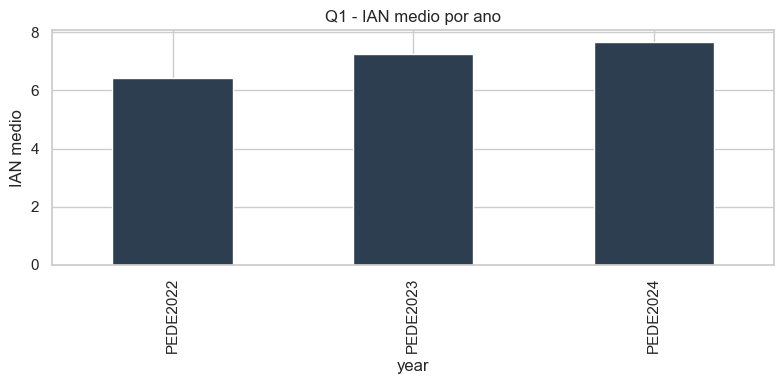

In [2]:
if 'ian' not in df.columns:
    print('Coluna ian nao encontrada.')
else:
    bins = [-np.inf, 3, 5, 7, np.inf]
    labels = ['Severamente deficiente', 'Moderadamente deficiente', 'Levemente deficiente', 'Adequado']
    ian_cat = pd.cut(df['ian'], bins=bins, labels=labels)
    print('Distribuicao geral de categorias IAN:')
    print(ian_cat.value_counts(dropna=False))
    if 'year' in df.columns:
        print('\nIAN medio por ano:')
        print(df.groupby('year', dropna=False)['ian'].mean().round(3))
        ax = df.groupby('year')['ian'].mean().sort_index().plot(kind='bar', figsize=(8,4), color='#2c3e50')
        ax.set_title('Q1 - IAN medio por ano')
        ax.set_ylabel('IAN medio')
        plt.tight_layout()
        plt.show()


## Q2: Tendencia de Desempenho do IDA


In [3]:
if 'ida' not in df.columns:
    print('Coluna ida nao encontrada.')
else:
    if 'year' in df.columns:
        t = df.groupby('year')['ida'].agg(['count','mean','std']).round(3)
        print('IDA por ano:')
        print(t)
    if {'year','phase','ida'}.issubset(df.columns):
        print('\nIDA por fase (ano mais recente):')
        y = sorted(df['year'].dropna().unique())[-1]
        print(df[df['year']==y].groupby('phase')['ida'].agg(['count','mean']).round(3))


IDA por ano:
          count   mean    std
year                         
PEDE2022    860  6.093  2.046
PEDE2023    937  6.663  1.595
PEDE2024   1055  6.351  2.132

IDA por fase (ano mais recente):
       count   mean
phase              
1A        14  7.571
1B        15  7.183
1C        14  7.286
1D        10  6.600
1E         8  6.312
...      ...    ...
8D         0    NaN
8E         0    NaN
8F         1  8.000
9          0    NaN
ALFA     196  7.320

[72 rows x 2 columns]


## Q3: Correlacao entre IEG, IDA e IPV


       ieg    ida    ipv
ieg  1.000  0.539  0.558
ida  0.539  1.000  0.557
ipv  0.558  0.557  1.000


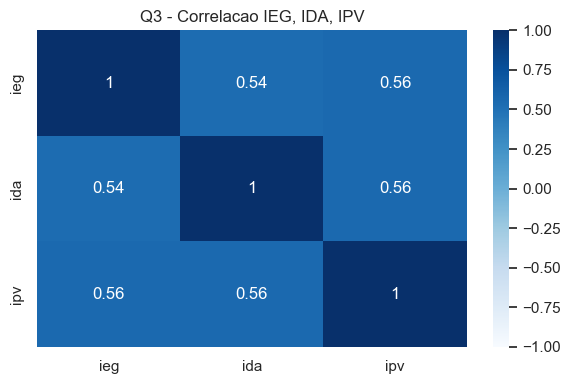

In [4]:
cols = [c for c in ['ieg','ida','ipv'] if c in df.columns]
if len(cols) < 2:
    print('Colunas insuficientes para correlacao.')
else:
    corr = df[cols].corr(numeric_only=True).round(3)
    print(corr)
    plt.figure(figsize=(6,4))
    sns.heatmap(corr, annot=True, cmap='Blues', vmin=-1, vmax=1)
    plt.title('Q3 - Correlacao IEG, IDA, IPV')
    plt.tight_layout()
    plt.show()


## Q4: Alinhamento entre IAA e IDA


Registros validos: 2851
Correlacao IAA x IDA: 0.115


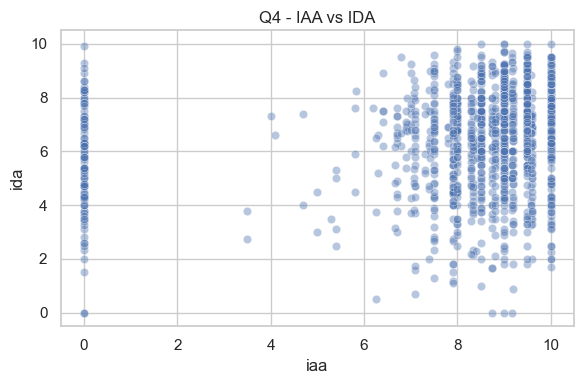

In [5]:
if {'iaa','ida'}.issubset(df.columns):
    sub = df[['iaa','ida']].dropna()
    print(f'Registros validos: {len(sub)}')
    print(f"Correlacao IAA x IDA: {sub['iaa'].corr(sub['ida']):.3f}")
    plt.figure(figsize=(6,4))
    sns.scatterplot(data=sub.sample(min(len(sub), 1200), random_state=42), x='iaa', y='ida', alpha=0.4)
    plt.title('Q4 - IAA vs IDA')
    plt.tight_layout()
    plt.show()
else:
    print('Colunas iaa/ida nao disponiveis.')


## Q5: Padroes de Risco Psicossocial (IPS)


In [6]:
if 'ips' in df.columns:
    q = pd.qcut(df['ips'], q=4, labels=['Q1_menor','Q2','Q3','Q4_maior'], duplicates='drop')
    print('Distribuicao por quartis de IPS:')
    print(q.value_counts(dropna=False))
    if 'ida' in df.columns:
        print('\nIDA medio por quartil de IPS:')
        print(df.assign(ips_q=q).groupby('ips_q')['ida'].mean().round(3))
else:
    print('Coluna ips nao encontrada.')


Distribuicao por quartis de IPS:
ips
Q2          1136
Q1_menor     731
Q3           528
Q4_maior     464
NaN          171
Name: count, dtype: int64

IDA medio por quartil de IPS:
ips_q
Q1_menor    6.259
Q2          6.206
Q3          6.530
Q4_maior    6.807
Name: ida, dtype: float64


## Q6: Consistencia entre IAN e IPP


Registros validos: 1992
Correlacao IAN x IPP: 0.123


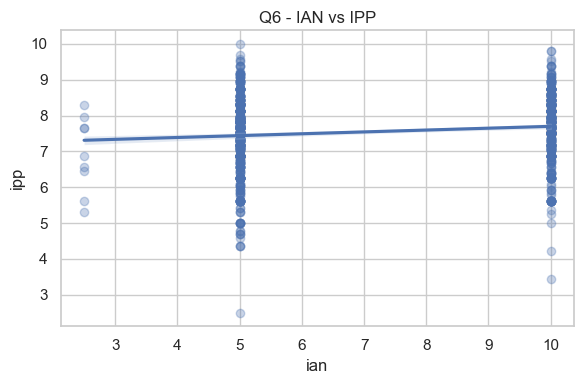

In [7]:
if {'ian','ipp'}.issubset(df.columns):
    sub = df[['ian','ipp']].dropna()
    print(f'Registros validos: {len(sub)}')
    print(f"Correlacao IAN x IPP: {sub['ian'].corr(sub['ipp']):.3f}")
    plt.figure(figsize=(6,4))
    sns.regplot(data=sub.sample(min(len(sub), 1200), random_state=42), x='ian', y='ipp', scatter_kws={'alpha':0.3})
    plt.title('Q6 - IAN vs IPP')
    plt.tight_layout()
    plt.show()
else:
    print('Colunas ian/ipp nao disponiveis.')


## Q7: Melhores Preditores do IPV


In [8]:
if 'ipv' not in df.columns:
    print('Coluna ipv nao encontrada.')
else:
    num = df.select_dtypes(include='number').columns.tolist()
    num = [c for c in num if c != 'ipv']
    if not num:
        print('Nao ha colunas numericas para comparacao.')
    else:
        corr = df[num + ['ipv']].corr(numeric_only=True)['ipv'].drop('ipv').abs().sort_values(ascending=False)
        print('Top 10 correlacoes absolutas com IPV:')
        print(corr.head(10).round(3))


Top 10 correlacoes absolutas com IPV:
inde_2024     0.758
inde_2022     0.621
ipp           0.607
inde_2023     0.566
ieg           0.558
ida           0.557
english       0.496
portuguese    0.477
math          0.455
birth_year    0.195
Name: ipv, dtype: float64


## Q8: Combinacoes que Elevam o INDE


In [9]:
inde_cols = [c for c in ['inde_2022','inde_2023','inde_2024'] if c in df.columns]
if not inde_cols:
    print('Colunas INDE nao disponiveis.')
else:
    tmp = df.copy()
    tmp['inde_combined'] = tmp[inde_cols].mean(axis=1)
    for c in ['ida','ieg','ips','ipp']:
        if c in tmp.columns:
            tmp[f'{c}_q'] = pd.qcut(tmp[c], 4, labels=['Q1','Q2','Q3','Q4'], duplicates='drop')
    group_cols = [c for c in ['ida_q','ieg_q','ips_q','ipp_q'] if c in tmp.columns]
    if group_cols:
        agg = tmp.groupby(group_cols, dropna=False)['inde_combined'].mean().reset_index()
        print('Top 10 combinacoes por INDE medio:')
        print(agg.sort_values('inde_combined', ascending=False).head(10))


Top 10 combinacoes por INDE medio:
    ida_q ieg_q ips_q ipp_q  inde_combined
469    Q4    Q4    Q4   NaN       8.881500
344    Q3    Q4    Q4   NaN       8.772000
604   NaN   NaN    Q1   NaN       8.714800
619   NaN   NaN    Q4   NaN       8.677000
466    Q4    Q4    Q4    Q2       8.624678
468    Q4    Q4    Q4    Q4       8.573337
463    Q4    Q4    Q3    Q4       8.546278
343    Q3    Q4    Q4    Q4       8.455246
460    Q4    Q4    Q3    Q1       8.415612
444    Q4    Q3    Q4   NaN       8.413800


## Q9: Sinais Precoces de Risco


In [10]:
risk_cols = [c for c in ['ian','ida','ips'] if c in df.columns]
if not risk_cols:
    print('Sem colunas para risco.')
else:
    tmp = df.copy()
    flags = []
    if 'ian' in tmp.columns: flags.append(tmp['ian'] <= tmp['ian'].quantile(0.25))
    if 'ida' in tmp.columns: flags.append(tmp['ida'] <= tmp['ida'].quantile(0.25))
    if 'ips' in tmp.columns: flags.append(tmp['ips'] <= tmp['ips'].quantile(0.25))
    tmp['early_risk'] = np.column_stack(flags).sum(axis=1) >= 2
    print(f"Taxa geral de risco precoce: {tmp['early_risk'].mean()*100:.2f}%")
    if 'year' in tmp.columns:
        print('Risco precoce por ano:')
        print((tmp.groupby('year')['early_risk'].mean()*100).round(2))


Taxa geral de risco precoce: 27.69%
Risco precoce por ano:
year
PEDE2022    29.88
PEDE2023    36.59
PEDE2024    18.25
Name: early_risk, dtype: float64


## Q10: Evolucao de Desempenho entre Fases


INDE médio por ano (todas as fases):
          count   mean    std
year                         
PEDE2022    860  7.036  1.018
PEDE2023    931  7.342  0.902
PEDE2024   1054  7.397  1.014

INDE médio por Fase × Ano:
year    PEDE2022  PEDE2023  PEDE2024
phase                               
ALFA         NaN     7.680     7.502
FASE 1       NaN     7.452       NaN
FASE 2       NaN     7.372       NaN
FASE 3       NaN     6.966       NaN
FASE 4       NaN     7.072       NaN
FASE 5       NaN     6.867       NaN
FASE 6       NaN     7.243       NaN
FASE 7       NaN     7.830       NaN
FASE 8       NaN       NaN       NaN


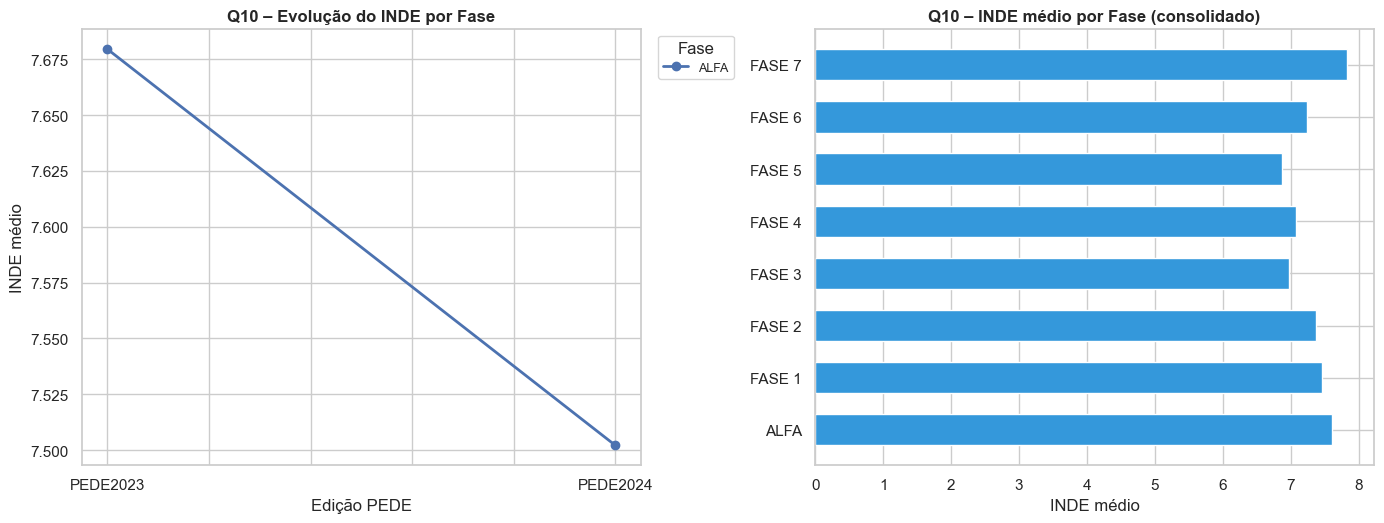

In [16]:
# Q10: Evolução longitudinal do INDE por Fase (programas FASE 1-7 + ALFA)
import re

inde_map = {'PEDE2022': 'inde_2022', 'PEDE2023': 'inde_2023', 'PEDE2024': 'inde_2024'}
available = {k: v for k, v in inde_map.items() if v in df.columns}

if not available or 'year' not in df.columns:
    print('Dados insuficientes para análise longitudinal.')
else:
    tmp = df.copy()
    tmp['inde_current'] = np.nan
    for yr, col in available.items():
        mask = tmp['year'] == yr
        tmp.loc[mask, 'inde_current'] = tmp.loc[mask, col]

    trend = (tmp.groupby('year')['inde_current']
               .agg(['count', 'mean', 'std'])
               .reindex(sorted(available.keys())))
    print("INDE médio por ano (todas as fases):")
    print(trend.round(3))

    if 'phase' in tmp.columns:
        # Filtrar apenas fases de programa (FASE 1-7 e ALFA), excluindo turmas granulares
        fase_pattern = re.compile(r'^(FASE\s*\d+|ALFA)$', re.IGNORECASE)
        mask_fase = tmp['phase'].astype(str).str.strip().apply(lambda x: bool(fase_pattern.match(x)))
        tmp_fases = tmp[mask_fase].copy()

        if tmp_fases.empty:
            print("\nNenhuma fase no formato FASE X / ALFA encontrada — exibindo top fases por volume.")
            top_fases = tmp.groupby('phase')['inde_current'].count().nlargest(10).index
            tmp_fases = tmp[tmp['phase'].isin(top_fases)].copy()

        pivot = (tmp_fases.groupby(['phase', 'year'])['inde_current']
                          .mean()
                          .unstack()
                          .reindex(columns=sorted(available.keys())))
        # Ordenar fases numericamente
        def _fase_sort_key(x):
            m = re.search(r'\d+', str(x))
            return (0, int(m.group())) if m else (-1, 0) if 'ALFA' in str(x).upper() else (1, 0)
        pivot = pivot.loc[sorted(pivot.index, key=_fase_sort_key)]

        print("\nINDE médio por Fase × Ano:")
        print(pivot.round(3))

        phase_mean = tmp_fases.groupby('phase')['inde_current'].mean()
        phase_mean = phase_mean.loc[sorted(phase_mean.index, key=_fase_sort_key)]

        fig, axes = plt.subplots(1, 2, figsize=(14, max(5, len(phase_mean) * 0.6)))

        pivot_valid = pivot.dropna(how='all').dropna(thresh=2, axis=0)
        if not pivot_valid.empty:
            pivot_valid.T.plot(ax=axes[0], marker='o', linewidth=2)
            axes[0].set_title('Q10 – Evolução do INDE por Fase', fontweight='bold')
            axes[0].set_ylabel('INDE médio')
            axes[0].set_xlabel('Edição PEDE')
            axes[0].legend(title='Fase', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
        else:
            axes[0].text(0.5, 0.5, 'Série temporal insuficiente\n(cada fase aparece em 1 ano)',
                         ha='center', va='center', transform=axes[0].transAxes, fontsize=11)

        axes[1].barh(phase_mean.index.astype(str), phase_mean.values, color='#3498db', height=0.6)
        axes[1].set_title('Q10 – INDE médio por Fase (consolidado)', fontweight='bold')
        axes[1].set_xlabel('INDE médio')

        plt.tight_layout()
        plt.show()


## Testes Estatísticos

Validação estatística das diferenças observadas entre grupos (Kruskal-Wallis + Mann-Whitney U; α = 0,05).


In [17]:
from scipy import stats

print("=== TESTES ESTATÍSTICOS (α = 0,05) ===\n")

def _sig(p): return "✓ Diferença significativa" if p < 0.05 else "Sem diferença significativa"

# INDE por ano (Kruskal-Wallis)
if 'inde_current' in tmp.columns and 'year' in tmp.columns:
    groups_yr = [tmp[tmp['year'] == y]['inde_current'].dropna() for y in sorted(available.keys())]
    groups_yr = [g for g in groups_yr if len(g) >= 5]
    if len(groups_yr) >= 2:
        H, p = stats.kruskal(*groups_yr)
        print(f"INDE por Ano    — Kruskal-Wallis H={H:.3f}, p={p:.4f}  →  {_sig(p)}")

# INDE por fase (Kruskal-Wallis)
if 'phase' in tmp.columns and 'inde_current' in tmp.columns:
    groups_ph = [tmp[tmp['phase'] == ph]['inde_current'].dropna()
                 for ph in sorted(tmp['phase'].dropna().unique())]
    groups_ph = [g for g in groups_ph if len(g) >= 5]
    if len(groups_ph) >= 2:
        H, p = stats.kruskal(*groups_ph)
        print(f"INDE por Fase   — Kruskal-Wallis H={H:.3f}, p={p:.4f}  →  {_sig(p)}")

# IAN por ano (Kruskal-Wallis)
if {'ian', 'year'}.issubset(df.columns):
    groups_ian = [df[df['year'] == y]['ian'].dropna() for y in df['year'].unique()]
    groups_ian = [g for g in groups_ian if len(g) >= 5]
    if len(groups_ian) >= 2:
        H, p = stats.kruskal(*groups_ian)
        print(f"IAN por Ano     — Kruskal-Wallis H={H:.3f}, p={p:.4f}  →  {_sig(p)}")

# IDA por ano (Kruskal-Wallis)
if {'ida', 'year'}.issubset(df.columns):
    groups_ida = [df[df['year'] == y]['ida'].dropna() for y in df['year'].unique()]
    groups_ida = [g for g in groups_ida if len(g) >= 5]
    if len(groups_ida) >= 2:
        H, p = stats.kruskal(*groups_ida)
        print(f"IDA por Ano     — Kruskal-Wallis H={H:.3f}, p={p:.4f}  →  {_sig(p)}")

# IDA: alta IAA vs baixa IAA (Mann-Whitney U)
if {'iaa', 'ida'}.issubset(df.columns):
    med = df['iaa'].median()
    g1 = df[df['iaa'] >= med]['ida'].dropna()
    g2 = df[df['iaa'] < med]['ida'].dropna()
    if len(g1) >= 5 and len(g2) >= 5:
        U, p = stats.mannwhitneyu(g1, g2, alternative='two-sided')
        print(f"IDA Alta-IAA vs Baixa-IAA — Mann-Whitney U={U:.0f}, p={p:.4f}  →  {_sig(p)}")

# IDA: IPS-Q1 vs restante (Mann-Whitney U)
if {'ips', 'ida'}.issubset(df.columns):
    q1_ips = df['ips'].quantile(0.25)
    g1 = df[df['ips'] <= q1_ips]['ida'].dropna()
    g2 = df[df['ips'] > q1_ips]['ida'].dropna()
    if len(g1) >= 5 and len(g2) >= 5:
        U, p = stats.mannwhitneyu(g1, g2, alternative='two-sided')
        print(f"IDA IPS-Q1 vs restante    — Mann-Whitney U={U:.0f}, p={p:.4f}  →  {_sig(p)}")


=== TESTES ESTATÍSTICOS (α = 0,05) ===

INDE por Ano    — Kruskal-Wallis H=64.678, p=0.0000  →  ✓ Diferença significativa
INDE por Fase   — Kruskal-Wallis H=358.403, p=0.0000  →  ✓ Diferença significativa
IAN por Ano     — Kruskal-Wallis H=123.679, p=0.0000  →  ✓ Diferença significativa
IDA por Ano     — Kruskal-Wallis H=26.551, p=0.0000  →  ✓ Diferença significativa
IDA Alta-IAA vs Baixa-IAA — Mann-Whitney U=1147994, p=0.0000  →  ✓ Diferença significativa
IDA IPS-Q1 vs restante    — Mann-Whitney U=712624, p=0.0053  →  ✓ Diferença significativa


## Q11: Insights Integrados


In [19]:
# Q11: Resumo executivo integrado
print('=== RESUMO EXECUTIVO — INSIGHTS INTEGRADOS ===\n')

insights = []

# Tendência IAN
if {'ian', 'year'}.issubset(df.columns):
    s = df.groupby('year')['ian'].mean().sort_index()
    delta = s.iloc[-1] - s.iloc[0]
    arrow = '↑' if delta > 0 else ('↓' if delta < 0 else '→')
    direction = 'melhora' if delta > 0 else ('piora' if delta < 0 else 'estável')
    insights.append(f"IAN: variação {delta:+.3f} de {s.index[0]} a {s.index[-1]} ({arrow} {direction})")

# Tendência IDA
if {'ida', 'year'}.issubset(df.columns):
    s = df.groupby('year')['ida'].mean().sort_index()
    delta = s.iloc[-1] - s.iloc[0]
    arrow = '↑' if delta > 0 else ('↓' if delta < 0 else '→')
    direction = 'melhora' if delta > 0 else ('piora' if delta < 0 else 'estável')
    insights.append(f"IDA: variação {delta:+.3f} de {s.index[0]} a {s.index[-1]} ({arrow} {direction})")

# Correlação IAA × IDA
if {'iaa', 'ida'}.issubset(df.columns):
    r = df[['iaa', 'ida']].corr().iloc[0, 1]
    force = 'forte' if abs(r) > 0.6 else ('moderada' if abs(r) > 0.3 else 'fraca')
    if abs(r) <= 0.3:
        note = 'autoavaliação não acompanha desempenho objetivo — gap de percepção relevante'
    elif abs(r) <= 0.6:
        note = 'autoavaliação parcialmente alinhada ao desempenho'
    else:
        note = 'autoavaliação reflete bem o desempenho acadêmico'
    insights.append(f"Correlação IAA × IDA = {r:.3f} (associação {force}) — {note}")

# Correlação IEG
if {'ieg', 'ida', 'ipv'}.issubset(df.columns):
    r_ida = df[['ieg', 'ida']].corr().iloc[0, 1]
    r_ipv = df[['ieg', 'ipv']].corr().iloc[0, 1]
    insights.append(
        f"IEG correlaciona com IDA ({r_ida:.3f}) e IPV ({r_ipv:.3f}) — "
        "engajamento impacta desempenho acadêmico e visão de futuro"
    )

# Melhores preditores do IPV
if 'ipv' in df.columns:
    num_c = [c for c in df.select_dtypes(include='number').columns if c != 'ipv']
    if num_c:
        top3 = df[num_c + ['ipv']].corr(numeric_only=True)['ipv'].drop('ipv').abs().nlargest(3)
        insights.append(
            "Principais preditores do IPV: " + ", ".join(f"{c} ({v:.3f})" for c, v in top3.items())
        )

# Impacto do IPS sobre IDA
if {'ips', 'ida'}.issubset(df.columns):
    q1_ips = df['ips'].quantile(0.25)
    ida_q1 = df[df['ips'] <= q1_ips]['ida'].mean()
    ida_rest = df[df['ips'] > q1_ips]['ida'].mean()
    diff = ida_q1 - ida_rest
    direction = 'menor' if diff < 0 else 'maior'
    insights.append(
        f"Alunos IPS no Q1 (maior pressão psicossocial): IDA médio {ida_q1:.3f} "
        f"vs {ida_rest:.3f} (Q2-Q4) — IDA {direction} em {abs(diff):.3f} pontos"
    )

# Taxa de risco precoce multidimensional
if {'ian', 'ida', 'ips'}.issubset(df.columns):
    risk_flags = sum([
        (df['ian'] <= df['ian'].quantile(0.25)).astype(int),
        (df['ida'] <= df['ida'].quantile(0.25)).astype(int),
        (df['ips'] <= df['ips'].quantile(0.25)).astype(int),
    ])
    taxa = (risk_flags >= 2).mean() * 100
    insights.append(f"Taxa de risco precoce multidimensional (≥2 indicadores no Q1): {taxa:.1f}% dos alunos")

for i, ins in enumerate(insights, 1):
    print(f'{i:2d}. {ins}')


=== RESUMO EXECUTIVO — INSIGHTS INTEGRADOS ===

 1. IAN: variação +1.259 de PEDE2022 a PEDE2024 (↑ melhora)
 2. IDA: variação +0.259 de PEDE2022 a PEDE2024 (↑ melhora)
 3. Correlação IAA × IDA = 0.115 (associação fraca) — autoavaliação não acompanha desempenho objetivo — gap de percepção relevante
 4. IEG correlaciona com IDA (0.539) e IPV (0.558) — engajamento impacta desempenho acadêmico e visão de futuro
 5. Principais preditores do IPV: inde_2024 (0.758), inde_2022 (0.621), ipp (0.607)
 6. Alunos IPS no Q1 (maior pressão psicossocial): IDA médio 6.259 vs 6.417 (Q2-Q4) — IDA menor em 0.158 pontos
 7. Taxa de risco precoce multidimensional (≥2 indicadores no Q1): 27.7% dos alunos
